In [2]:
import pandas as pd

df = pd.read_csv("../artifacts/raw/train.csv")

In [3]:
df = df.drop(columns=["Id"])

In [4]:
FEATURES = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "Fireplaces",
    "LotArea"
]

TARGET = "SalePrice"

df = df[FEATURES + [TARGET]]

In [5]:
df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
YearRemodAdd    0
MasVnrArea      8
Fireplaces      0
LotArea         0
SalePrice       0
dtype: int64

In [6]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(
    df["MasVnrArea"].median()
)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
YearRemodAdd    0
MasVnrArea      0
Fireplaces      0
LotArea         0
SalePrice       0
dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X["MasVnrArea"] = X["MasVnrArea"].fillna(
    X["MasVnrArea"].median()
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 13)
X_test : (292, 13)
y_train: (1168,)
y_test : (292,)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = root_mean_squared_error(
        y_test,
        predictions
    )

    results[name] = {
        "R2": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    }

for model_name, metrics in results.items():
    print()
    print(model_name)
    print(metrics)


Linear Regression
{'R2': 0.8088, 'MAE': 24138.52, 'RMSE': 38291.01}

Decision Tree
{'R2': 0.8063, 'MAE': 25862.94, 'RMSE': 38545.67}

Random Forest
{'R2': 0.8911, 'MAE': 18200.22, 'RMSE': 28897.97}

Gradient Boosting
{'R2': 0.9015, 'MAE': 18504.75, 'RMSE': 27481.71}


In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

train_pred = gb.predict(X_train)
test_pred = gb.predict(X_test)

print(
    "Train R2:",
    r2_score(y_train, train_pred)
)

print(
    "Test R2:",
    r2_score(y_test, test_pred)
)

Train R2: 0.947129288222805
Test R2: 0.9015368914865347


In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)

print(
    "XGBoost R2:",
    r2_score(y_test, preds)
)

XGBoost R2: 0.8904972076416016


House Price Distribution

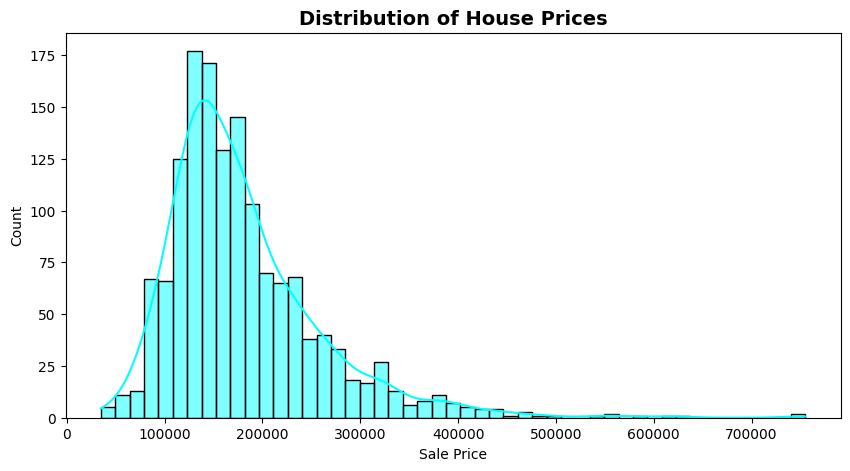

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df["SalePrice"], kde=True, color="cyan")

plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

Correlation With SalePrice

In [14]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
LotArea         0.263843
Name: SalePrice, dtype: float64

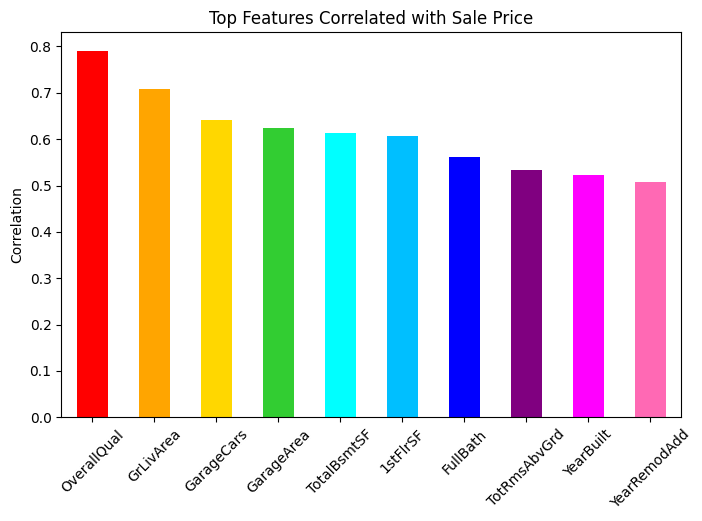

In [29]:
import matplotlib.pyplot as plt

top_corr = corr[1:11]

colors = [
    "red", "orange", "gold", "limegreen", "cyan",
    "deepskyblue", "blue", "purple", "magenta", "hotpink"
]

plt.figure(figsize=(8,5))
top_corr.plot(kind="bar", color=colors)

plt.title("Top Features Correlated with Sale Price")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

Missing Values Analysis

In [22]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(12,6))
    missing.head(15).plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.ylabel("Count")
    plt.show()
else:
    print("No missing values found.")

No missing values found.


Living Area vs Sale Price

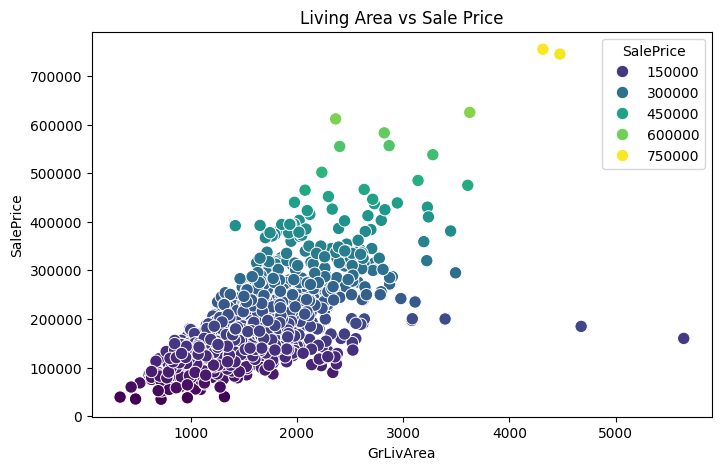

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    hue="SalePrice",
    palette="viridis",
    s=80
)

plt.title("Living Area vs Sale Price")
plt.show()

Overall Quality vs Sale Price

C:\Users\dimpa\AppData\Local\Temp\ipykernel_15336\3694809192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


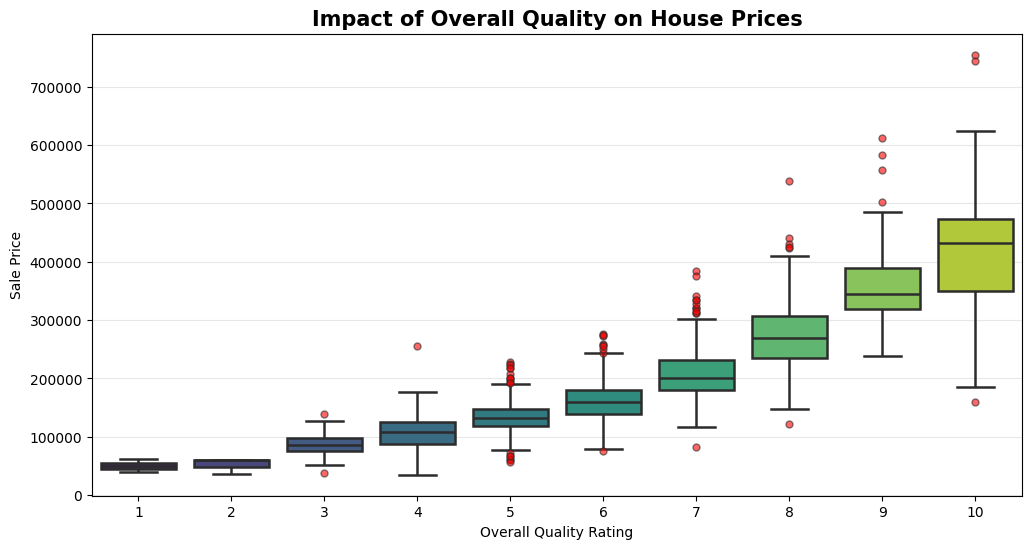

In [35]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df,
    palette="viridis",
    linewidth=1.8,
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markersize": 5,
        "alpha": 0.6
    }
)

plt.title("Impact of Overall Quality on House Prices",
          fontsize=15,
          fontweight="bold")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price")
plt.grid(axis="y", alpha=0.3)

plt.show()

Model Comparison

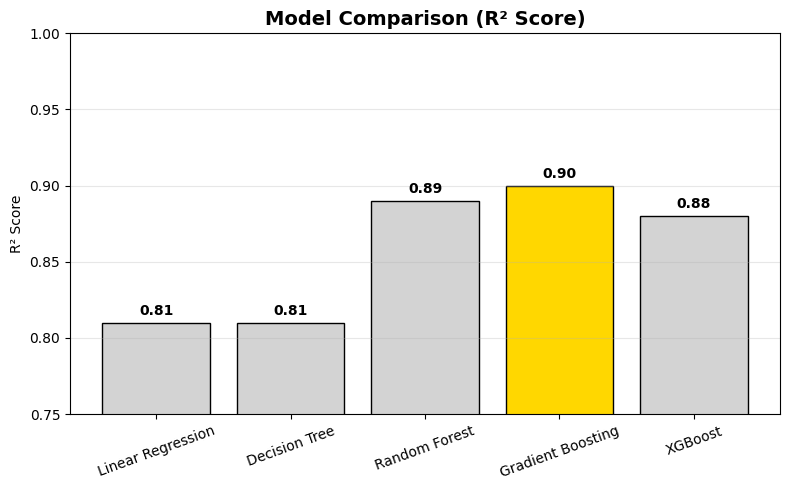

In [ ]:
import matplotlib.pyplot as plt

results = {
    "Linear Regression": 0.81,
    "Decision Tree": 0.81,
    "Random Forest": 0.89,
    "Gradient Boosting": 0.90,
    "XGBoost": 0.88
}

colors = [
    "lightgray",
    "lightgray",
    "lightgray",
    "gold",     
    "lightgray"
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    results.keys(),
    results.values(),
    color=colors,
    edgecolor="black"
)

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Model Comparison (R² Score)", fontsize=14, fontweight="bold")
plt.ylabel("R² Score")
plt.ylim(0.75, 1.0)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()